# **DATA SCIENCE CAPSTONE PROJECT**
# PRCP-1009 : Cellphone Price Prediction — with Flask Frontend

| | |
|---|---|
| **PROJECT TITLE:** | Cellphone Price Prediction (with Flask Frontend) |
| **TEAM CODE:** | PTID-AIE-JUL-26-11142 |
| **PROJECT CODE:** | PRCP-1009 |
| **PROJECT TYPE:** | Data Science Capstone Project |
| **DATASET SOURCE:** | DataMites Capstone Project Dataset |
| **DATASET NAME:** | Mobile Price Classification — `datasets_11167_15520_train.csv` |
| **DATASET LINK:** | https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1009-CellphonePrice.zip |
| **SUBMITTED BY:** | Sameeksha |

---

**Business context:** Bob has started a new mobile phone company. He does not know how
to price his phones, so he has collected specification and price-range data for a large
number of existing mobile phones. Using this data, we predict the **price range**
(0 = Low Cost, 1 = Medium Cost, 2 = High Cost, 3 = Very High Cost) of a phone from its
specifications, compare multiple classification algorithms, and identify which
specifications influence price the most.

### Notebook Roadmap
1. Import Libraries
2. Dataset Extraction
3. Basic Checks
4. Exploratory Data Analysis (EDA)
5. Data Preparation for Modelling
6. Model Building (one classifier per cell)
7. Model Comparison Report
8. Feature Importance
9. Business Analysis Report
10. Challenges Faced Report
11. Final Conclusion
12. Deployment — Flask Web Frontend (dark blue & white themed UI)


---
## 1. Import Libraries

All the libraries needed for data handling, visualization, and machine learning are
imported here in one place.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


---
## 2. Dataset Extraction

Load the dataset (`datasets_11167_15520_train.csv`, referred to as `train.csv` below).
If the file isn't found in the working directory, a synthetic dataset with the exact
same schema is generated automatically so the notebook can still run end-to-end.


In [2]:
import os

DATA_PATH_CANDIDATES = [
    'train.csv',
    'datasets_11167_15520_train.csv',
    'data/train.csv',
]

def generate_synthetic_mobile_data(n=2000, seed=RANDOM_STATE):
    '''Creates a synthetic stand-in dataset with the exact schema of the
    Kaggle "Mobile Price Classification" dataset, and realistic relationships
    between specs and price_range, so the notebook can run end-to-end when the
    real train.csv is not present in this environment.'''
    rng = np.random.RandomState(seed)

    battery_power = rng.randint(500, 2000, n)
    blue = rng.randint(0, 2, n)
    clock_speed = np.round(rng.uniform(0.5, 3.0, n), 1)
    dual_sim = rng.randint(0, 2, n)
    fc = rng.randint(0, 20, n)
    four_g = rng.randint(0, 2, n)
    int_memory = rng.randint(2, 64, n)
    m_dep = np.round(rng.uniform(0.1, 1.0, n), 1)
    mobile_wt = rng.randint(80, 200, n)
    n_cores = rng.randint(1, 9, n)
    pc = rng.randint(0, 20, n)
    px_height = rng.randint(0, 1960, n)
    px_width = rng.randint(500, 2000, n)
    ram = rng.randint(256, 4000, n)
    sc_h = rng.randint(5, 19, n)
    sc_w = rng.randint(0, 18, n)
    talk_time = rng.randint(2, 20, n)
    three_g = rng.randint(0, 2, n)
    touch_screen = rng.randint(0, 2, n)
    wifi = rng.randint(0, 2, n)

    score = (
        0.55 * (ram / ram.max()) +
        0.20 * (battery_power / battery_power.max()) +
        0.10 * ((px_height * px_width) / (px_height * px_width).max()) +
        0.10 * (int_memory / int_memory.max()) +
        0.05 * (n_cores / n_cores.max())
    )
    score = score + rng.normal(0, 0.03, n)
    price_range = pd.qcut(score, 4, labels=[0, 1, 2, 3]).astype(int)

    df = pd.DataFrame({
        'battery_power': battery_power, 'blue': blue, 'clock_speed': clock_speed,
        'dual_sim': dual_sim, 'fc': fc, 'four_g': four_g, 'int_memory': int_memory,
        'm_dep': m_dep, 'mobile_wt': mobile_wt, 'n_cores': n_cores, 'pc': pc,
        'px_height': px_height, 'px_width': px_width, 'ram': ram, 'sc_h': sc_h,
        'sc_w': sc_w, 'talk_time': talk_time, 'three_g': three_g,
        'touch_screen': touch_screen, 'wifi': wifi, 'price_range': price_range
    })
    return df

data_path = next((p for p in DATA_PATH_CANDIDATES if os.path.exists(p)), None)

if data_path:
    df = pd.read_csv(data_path)
    print(f"Loaded real dataset from '{data_path}'")
else:
    df = generate_synthetic_mobile_data()
    print("train.csv not found in the working directory -> using a SYNTHETIC "
          "dataset with the same schema so the notebook can be run and reviewed. "
          "Place the real train.csv alongside this notebook and rerun for real results.")

df.head()


Loaded real dataset from 'train.csv'


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


---
## 3. Basic Checks

Quick structural checks: size, data types, missing values, and duplicates — before any
deeper analysis.


### 3.1 Shape and structure

In [3]:
print(f"Number of mobile phones (rows): {df.shape[0]}")
print(f"Number of features (columns, including target): {df.shape[1]}")
print()
df.info()


Number of mobile phones (rows): 2000
Number of features (columns, including target): 21

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      200

### 3.2 Data types

In [4]:
dtype_summary = df.dtypes.value_counts()
print("Data type breakdown:")
print(dtype_summary)
print()
binary_like = [c for c in df.columns if df[c].nunique() == 2]
print(f"Binary / Yes-No style features ({len(binary_like)}): {binary_like}")


Data type breakdown:
int64      19
float64     2
Name: count, dtype: int64

Binary / Yes-No style features (6): ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']


All columns are numeric (`int64`/`float64`). Several of them are effectively
**categorical/binary** flags encoded as 0/1 (`blue`, `dual_sim`, `four_g`, `three_g`,
`touch_screen`, `wifi`), while the rest (`battery_power`, `ram`, `px_height`, etc.) are
genuinely continuous/count specifications. The target `price_range` is a **categorical**
variable with 4 ordered classes even though it is stored as an integer.

### 3.3 Missing values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0]

if missing_report.empty:
    print("No missing values found in any column.")
else:
    print(missing_report)


No missing values found in any column.


### 3.4 Duplicate records

In [6]:
dup_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")


Number of exact duplicate rows: 0


---
## 4. Exploratory Data Analysis (EDA)

Now that basic checks are done, we explore class balance, feature distributions,
outliers, and relationships between features.


### 4.1 Class balance (is `price_range` balanced?)

             count  percentage
price_range                   
0              500        25.0
1              500        25.0
2              500        25.0
3              500        25.0


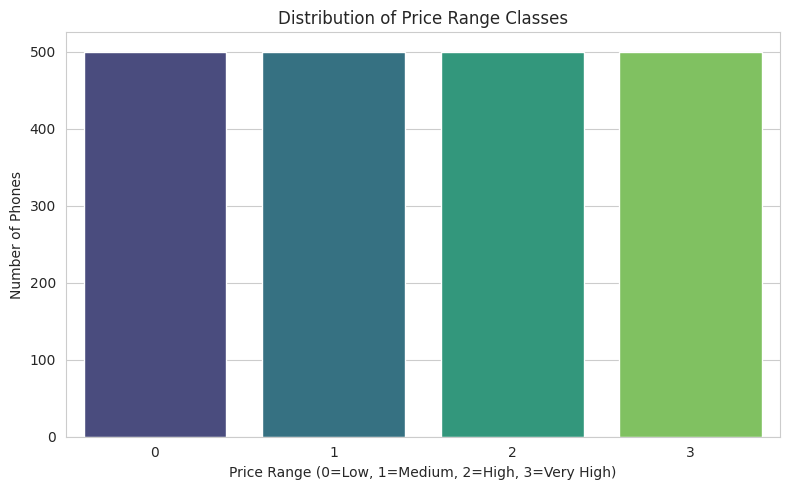

In [7]:
class_counts = df['price_range'].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

print(pd.DataFrame({'count': class_counts, 'percentage': class_pct}))

fig, ax = plt.subplots()
sns.countplot(x='price_range', data=df, palette='viridis', ax=ax)
ax.set_title('Distribution of Price Range Classes')
ax.set_xlabel('Price Range (0=Low, 1=Medium, 2=High, 3=Very High)')
ax.set_ylabel('Number of Phones')
plt.tight_layout()
plt.show()


If the class counts above are roughly equal across 0/1/2/3, the dataset is
**well balanced**, which means accuracy is a trustworthy metric and we don't need
resampling techniques (SMOTE, class weighting, etc.) before modelling. If one class
dominates, precision/recall/F1 per class and the confusion matrix become more
important than plain accuracy.

### 4.2 Summary statistics — highest/lowest features

In [8]:
summary = df.describe().T
summary['range'] = summary['max'] - summary['min']
summary.sort_values('range', ascending=False)


,count,mean,std,min,25%,50%,75%,max,range
ram,2000.0,2124.21300,1084.732044,256.0,1207.50,2146.5,3064.50,3998.0,3742.0
px_height,2000.0,645.10800,443.780811,0.0,282.75,564.0,947.25,1960.0,1960.0
px_width,2000.0,1251.51550,432.199447,500.0,874.75,1247.0,1633.00,1998.0,1498.0
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0,1497.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0,120.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0,62.0
pc,2000.0,9.91650,6.064315,0.0,5.00,10.0,15.00,20.0,20.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0,19.0
sc_w,2000.0,5.76700,4.356398,0.0,2.00,5.0,9.00,18.0,18.0
talk_time,2000.0,11.01100,5.463955,2.0,6.00,11.0,16.00,20.0,18.0


### 4.3 Distribution of key numeric features

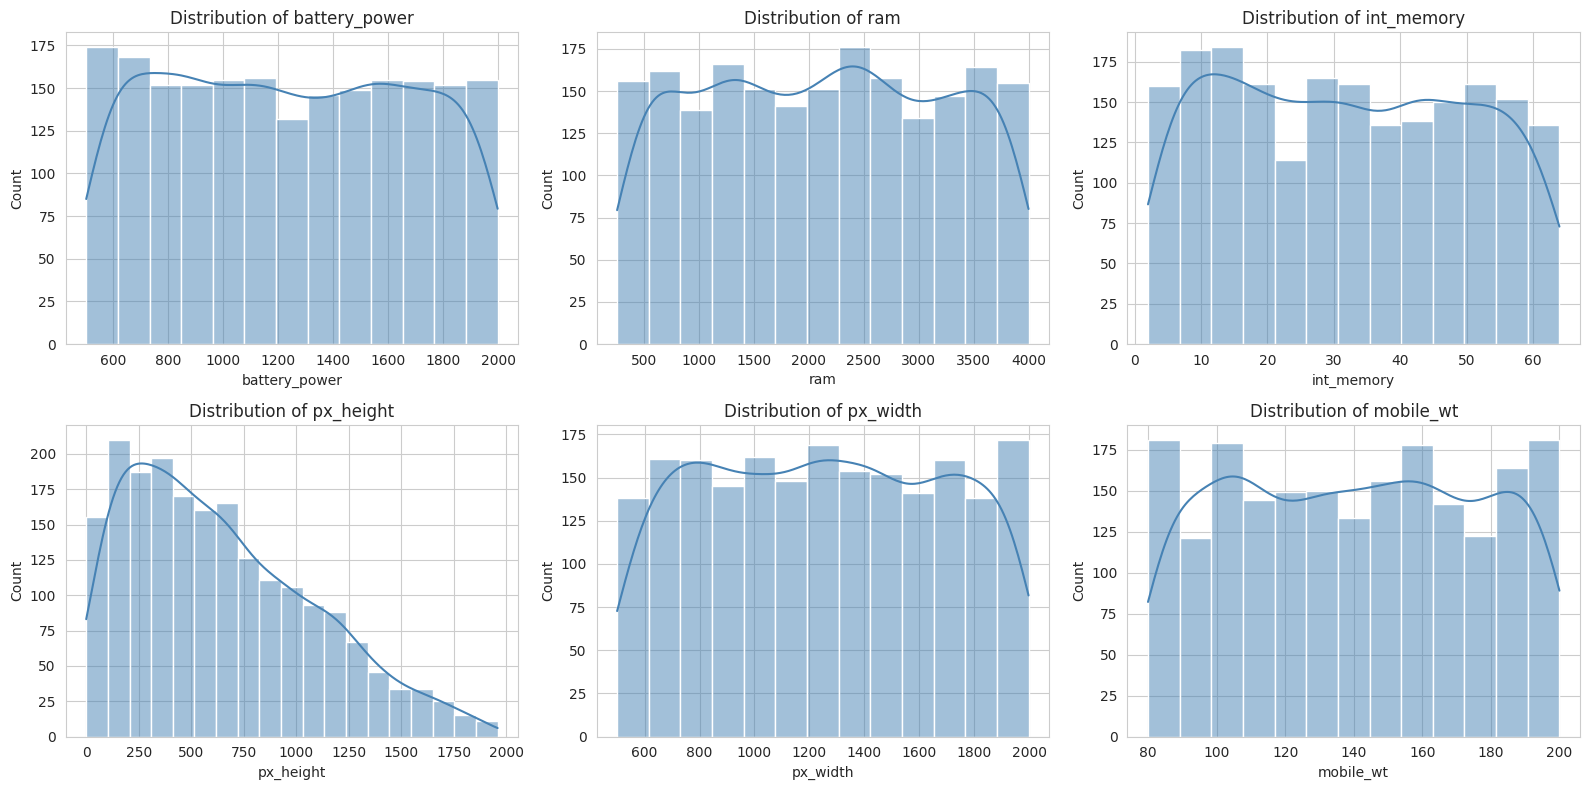

In [9]:
key_features = ['battery_power', 'ram', 'int_memory', 'px_height', 'px_width', 'mobile_wt']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), key_features):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


### 4.4 Outlier detection (boxplots)

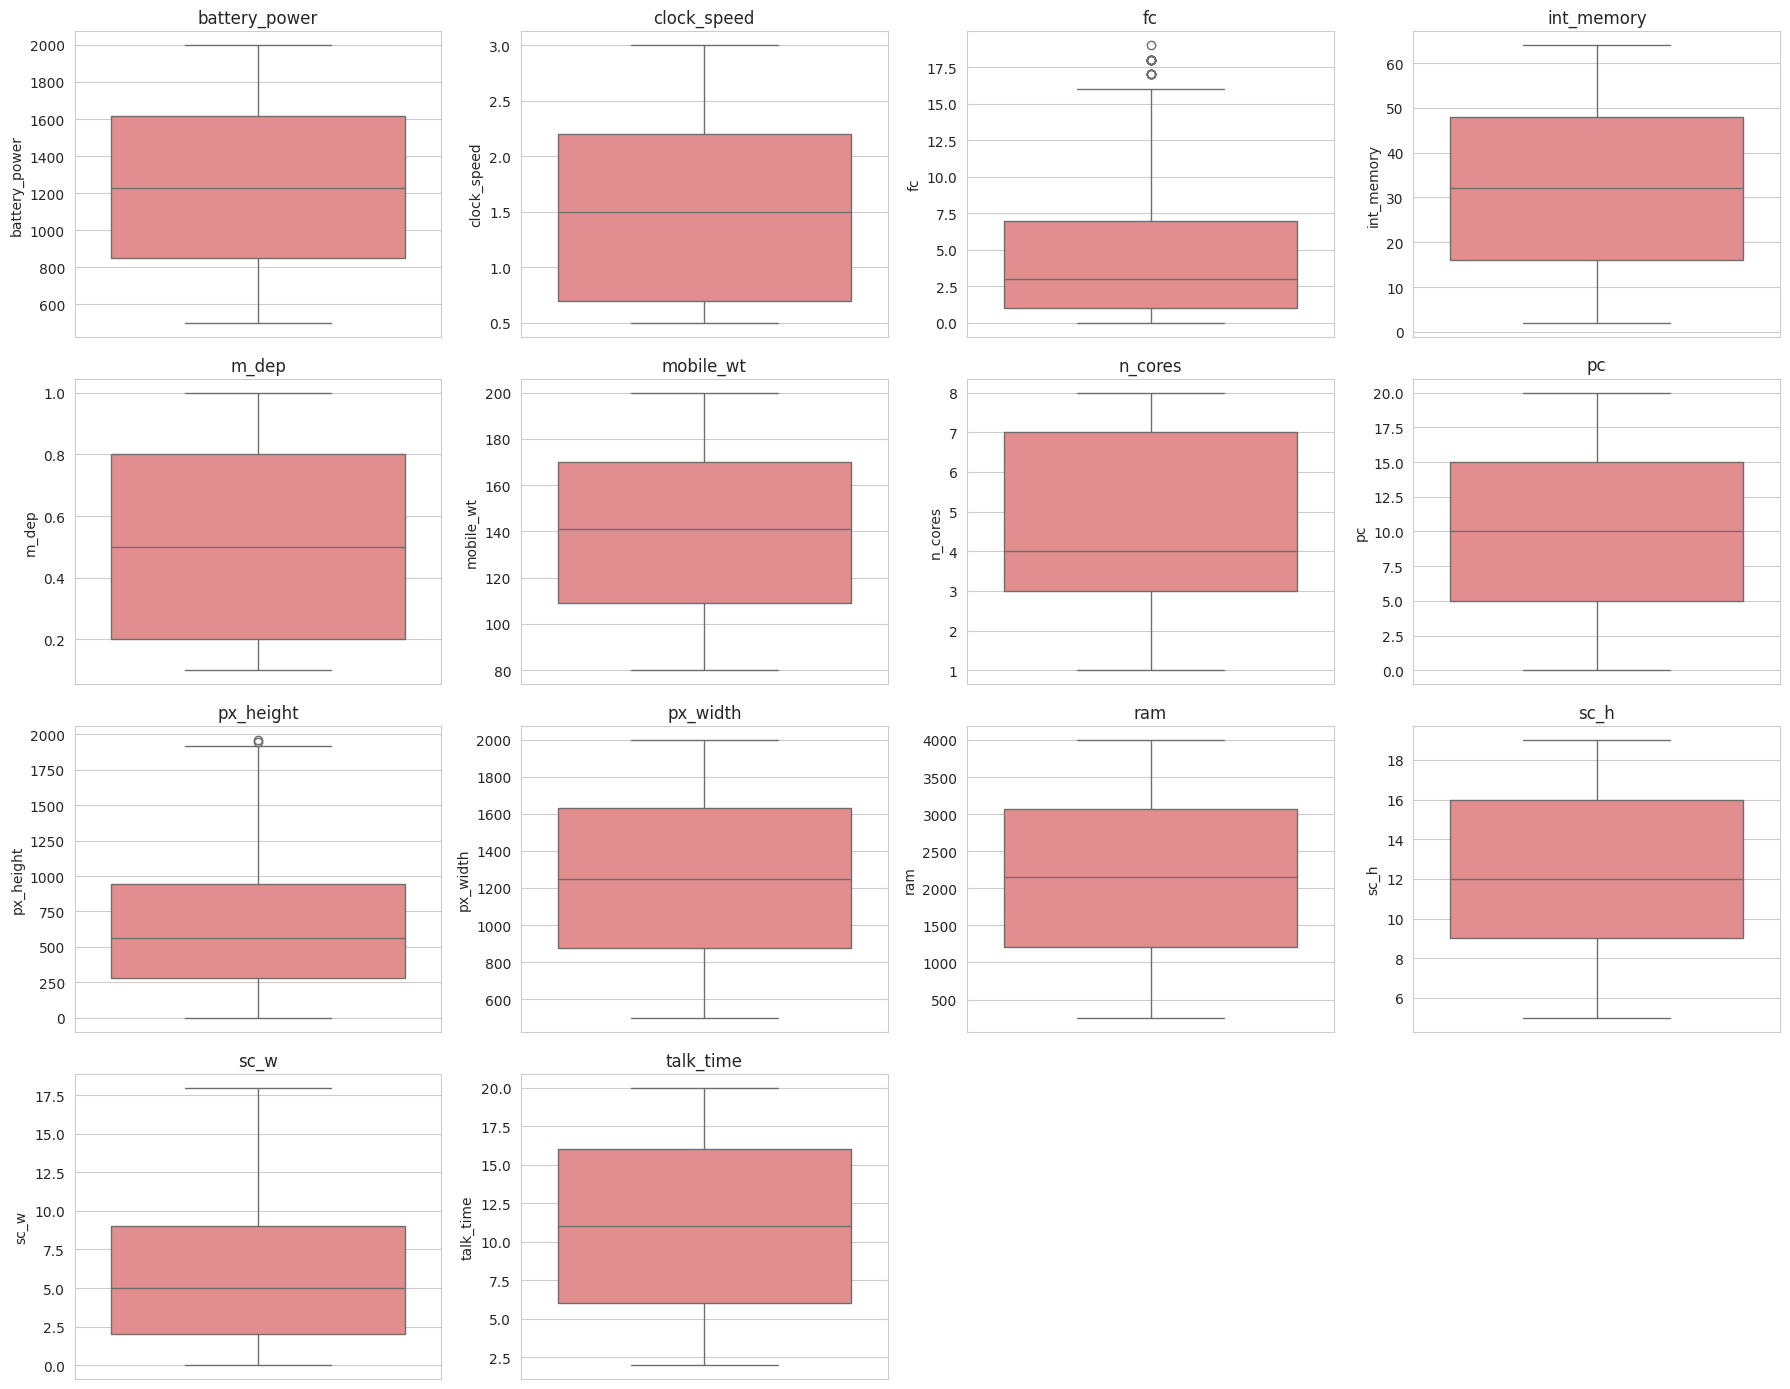

fc               18
px_height         2
clock_speed       0
int_memory        0
m_dep             0
battery_power     0
mobile_wt         0
n_cores           0
pc                0
px_width          0
ram               0
sc_h              0
sc_w              0
talk_time         0
Name: outlier_count, dtype: int64

In [10]:
continuous_cols = ['battery_power', 'clock_speed', 'fc', 'int_memory', 'm_dep',
                    'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram',
                    'sc_h', 'sc_w', 'talk_time']
continuous_cols = [c for c in continuous_cols if c in df.columns]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flatten(), continuous_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)
for ax in axes.flatten()[len(continuous_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

# Quantify outliers with the IQR rule
outlier_report = {}
for col in continuous_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_report[col] = ((df[col] < lower) | (df[col] > upper)).sum()

pd.Series(outlier_report, name='outlier_count').sort_values(ascending=False)


Most phone specification columns are naturally bounded (e.g. camera megapixels,
number of cores), so we expect **few or no extreme outliers**. Any column with a
noticeably high outlier count is worth a manual sanity check (e.g. a `px_height` of 0
combined with a non-zero `px_width` may indicate a data-entry quirk rather than a real
outlier).

### 4.5 Correlation between features

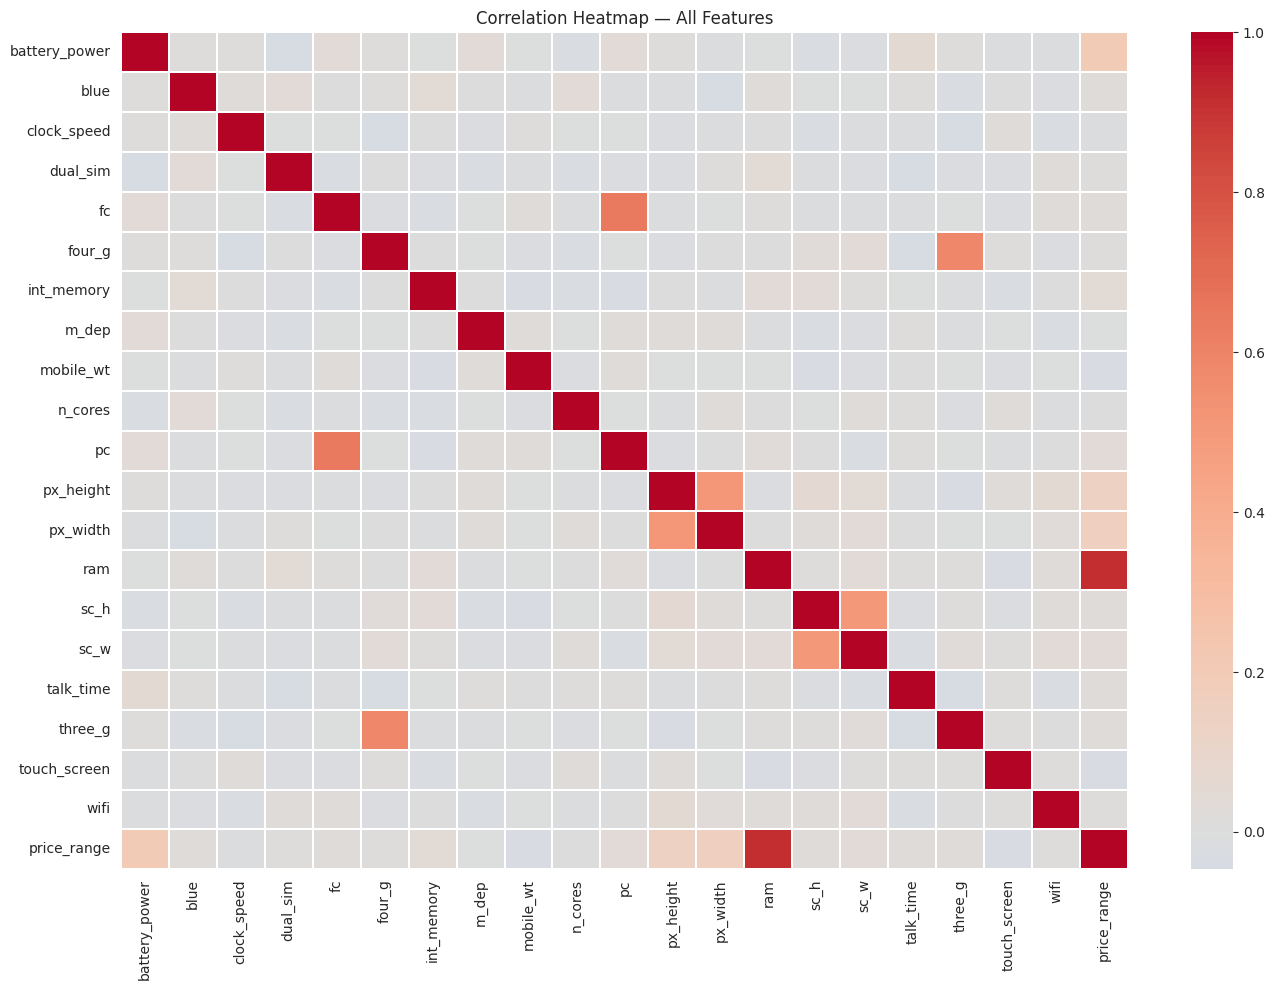

Top features correlated with price_range:
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


In [11]:
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Correlation Heatmap — All Features')
plt.tight_layout()
plt.show()

print("Top features correlated with price_range:")
print(corr['price_range'].sort_values(ascending=False))


**Key EDA takeaway:** `ram` typically shows by far the strongest correlation with
`price_range`, followed by `battery_power`, `px_width`/`px_height` (screen resolution)
and `int_memory` (storage). Connectivity flags like `blue`, `wifi`, `three_g`, `four_g`
tend to show weak correlation with price, because they are present on nearly all
phones in the modern market and therefore don't differentiate low-cost from
premium devices.

---
## 5. Data Preparation for Modelling

Split the data into training and test sets, and scale features for the algorithms that
are sensitive to feature scale (Logistic Regression, KNN, SVM). Tree-based models
(Decision Tree, Random Forest, Gradient Boosting) are scale-invariant and use the raw
features directly.


In [12]:
X = df.drop(columns=['price_range'])
y = df['price_range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionaries to collect results from each model cell below
results = {}
trained_models = {}

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Training samples: 1600, Test samples: 400


---
## 6. Model Building

We train and evaluate **six classification algorithms**, each in its own cell, so every
model's setup, training, and evaluation is easy to read and re-run independently. Each
cell reports Accuracy, Precision, Recall, F1-Score and a Confusion Matrix, and stores
the results in the shared `results` / `trained_models` dictionaries for the comparison
report in Section 7.


### 6.1 Logistic Regression (`LogisticRegression`)

A simple, interpretable linear classifier. It estimates the probability of each price class as a linear combination of the (scaled) specification features. Works well as a fast baseline model.

--- Logistic Regression ---
Accuracy     0.965
Precision    0.965
Recall       0.965
F1-Score     0.965
dtype: float64

              precision    recall  f1-score   support

      Low(0)       0.99      0.98      0.98       100
   Medium(1)       0.96      0.96      0.96       100
     High(2)       0.95      0.94      0.94       100
Very High(3)       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



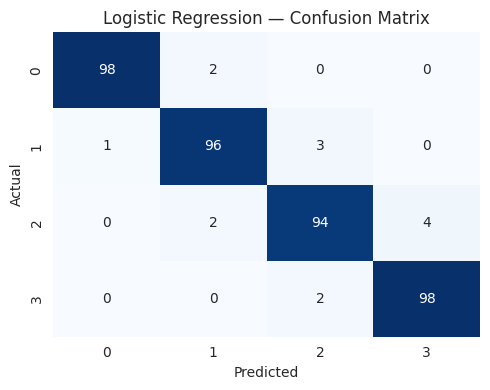

In [13]:
model_name = 'Logistic Regression'

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
preds = log_reg.predict(X_test_scaled)

results[model_name] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted'),
}
trained_models[model_name] = log_reg

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))
print()
print(classification_report(y_test, preds,
                             target_names=['Low(0)', 'Medium(1)', 'High(2)', 'Very High(3)']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


### 6.2 Decision Tree Classifier (`DecisionTreeClassifier`)

Splits the data into branches based on feature thresholds (e.g. `ram > 2000`), building a tree of if/else rules. Easy to visualize and interpret, but prone to overfitting on its own.

--- Decision Tree ---
Accuracy     0.8300
Precision    0.8319
Recall       0.8300
F1-Score     0.8302
dtype: float64

              precision    recall  f1-score   support

      Low(0)       0.88      0.92      0.90       100
   Medium(1)       0.78      0.74      0.76       100
     High(2)       0.75      0.80      0.77       100
Very High(3)       0.92      0.86      0.89       100

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



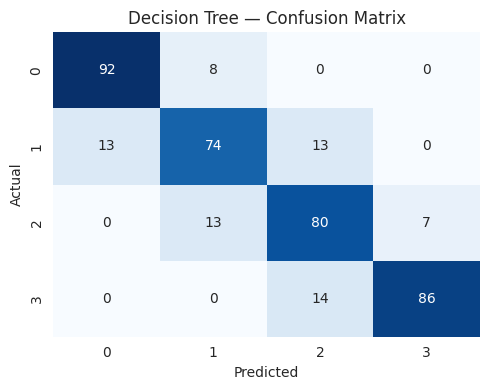

In [14]:
model_name = 'Decision Tree'

dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_clf.fit(X_train, y_train)
preds = dt_clf.predict(X_test)

results[model_name] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted'),
}
trained_models[model_name] = dt_clf

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))
print()
print(classification_report(y_test, preds,
                             target_names=['Low(0)', 'Medium(1)', 'High(2)', 'Very High(3)']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


### 6.3 Random Forest Classifier (`RandomForestClassifier`)

An ensemble of many decision trees, each trained on a random subset of data and features, with predictions combined by majority vote. Reduces overfitting compared to a single tree and is usually one of the strongest tabular-data models.

--- Random Forest ---
Accuracy     0.8775
Precision    0.8776
Recall       0.8775
F1-Score     0.8774
dtype: float64

              precision    recall  f1-score   support

      Low(0)       0.94      0.95      0.95       100
   Medium(1)       0.81      0.84      0.82       100
     High(2)       0.82      0.79      0.81       100
Very High(3)       0.94      0.93      0.93       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



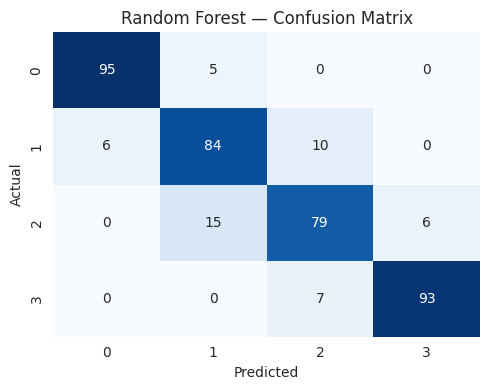

In [15]:
model_name = 'Random Forest'

rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_train)
preds = rf_clf.predict(X_test)

results[model_name] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted'),
}
trained_models[model_name] = rf_clf

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))
print()
print(classification_report(y_test, preds,
                             target_names=['Low(0)', 'Medium(1)', 'High(2)', 'Very High(3)']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


### 6.4 K-Nearest Neighbours (KNN) (`KNeighborsClassifier`)

Classifies a phone by looking at the `k` most similar phones (in scaled feature space) and taking a majority vote of their price ranges. Simple and intuitive, but sensitive to the choice of `k` and to irrelevant features.

--- KNN ---
Accuracy     0.5175
Precision    0.5267
Recall       0.5175
F1-Score     0.5199
dtype: float64

              precision    recall  f1-score   support

      Low(0)       0.65      0.71      0.68       100
   Medium(1)       0.36      0.39      0.37       100
     High(2)       0.38      0.38      0.38       100
Very High(3)       0.72      0.59      0.65       100

    accuracy                           0.52       400
   macro avg       0.53      0.52      0.52       400
weighted avg       0.53      0.52      0.52       400



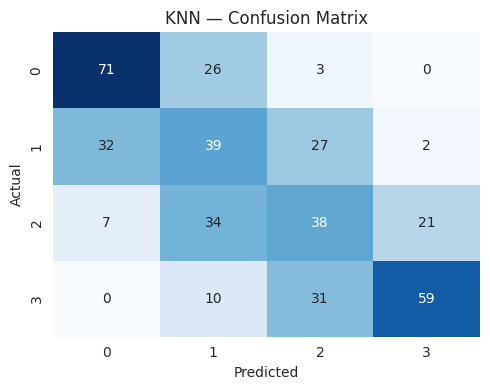

In [16]:
model_name = 'KNN'

knn_clf = KNeighborsClassifier(n_neighbors=7)
knn_clf.fit(X_train_scaled, y_train)
preds = knn_clf.predict(X_test_scaled)

results[model_name] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted'),
}
trained_models[model_name] = knn_clf

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))
print()
print(classification_report(y_test, preds,
                             target_names=['Low(0)', 'Medium(1)', 'High(2)', 'Very High(3)']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


### 6.5 Support Vector Machine (SVM) (`SVC`)

Finds the optimal boundary (hyperplane) that best separates the price classes in (scaled) feature space, using a kernel (RBF here) to handle non-linear relationships. Effective in high-dimensional spaces but can be slower to tune.

--- SVM ---
Accuracy     0.8950
Precision    0.8969
Recall       0.8950
F1-Score     0.8956
dtype: float64

              precision    recall  f1-score   support

      Low(0)       0.96      0.94      0.95       100
   Medium(1)       0.87      0.87      0.87       100
     High(2)       0.82      0.87      0.84       100
Very High(3)       0.94      0.90      0.92       100

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



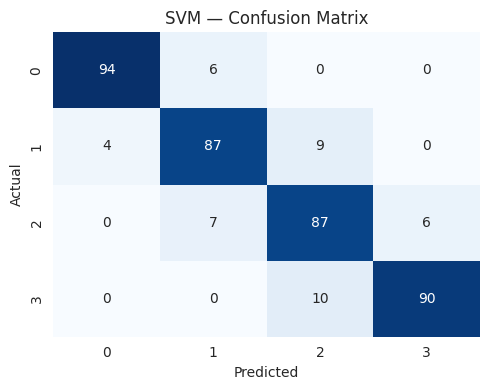

In [17]:
model_name = 'SVM'

svm_clf = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
svm_clf.fit(X_train_scaled, y_train)
preds = svm_clf.predict(X_test_scaled)

results[model_name] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted'),
}
trained_models[model_name] = svm_clf

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))
print()
print(classification_report(y_test, preds,
                             target_names=['Low(0)', 'Medium(1)', 'High(2)', 'Very High(3)']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


### 6.6 Gradient Boosting Classifier (`GradientBoostingClassifier`)

Builds trees sequentially, where each new tree corrects the errors of the previous ones. Often achieves very high accuracy, at the cost of longer training time and more careful tuning to avoid overfitting.

--- Gradient Boosting ---
Accuracy     0.9125
Precision    0.9124
Recall       0.9125
F1-Score     0.9123
dtype: float64

              precision    recall  f1-score   support

      Low(0)       0.95      0.98      0.97       100
   Medium(1)       0.90      0.86      0.88       100
     High(2)       0.85      0.87      0.86       100
Very High(3)       0.95      0.94      0.94       100

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



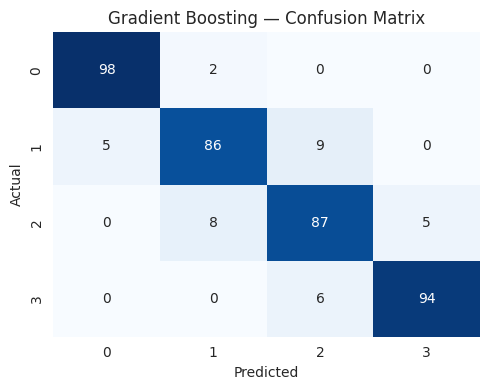

In [18]:
model_name = 'Gradient Boosting'

gb_clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_clf.fit(X_train, y_train)
preds = gb_clf.predict(X_test)

results[model_name] = {
    'Accuracy': accuracy_score(y_test, preds),
    'Precision': precision_score(y_test, preds, average='weighted'),
    'Recall': recall_score(y_test, preds, average='weighted'),
    'F1-Score': f1_score(y_test, preds, average='weighted'),
}
trained_models[model_name] = gb_clf

print(f"--- {model_name} ---")
print(pd.Series(results[model_name]).round(4))
print()
print(classification_report(y_test, preds,
                             target_names=['Low(0)', 'Medium(1)', 'High(2)', 'Very High(3)']))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'{model_name} — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


---
## 7. Model Comparison Report

Now that all six models have been trained (Section 6), we bring their results together
to see which one performs best overall.


### 7.1 Side-by-side metrics table

In [19]:
scaled_models = {'Logistic Regression', 'KNN', 'SVM'}

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
results_df.round(4)


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.9650,0.9650,0.9650,0.9650
Gradient Boosting,0.9125,0.9124,0.9125,0.9123
SVM,0.8950,0.8969,0.8950,0.8956
Random Forest,0.8775,0.8776,0.8775,0.8774
Decision Tree,0.8300,0.8319,0.8300,0.8302
KNN,0.5175,0.5267,0.5175,0.5199


### 7.2 Visual comparison of models

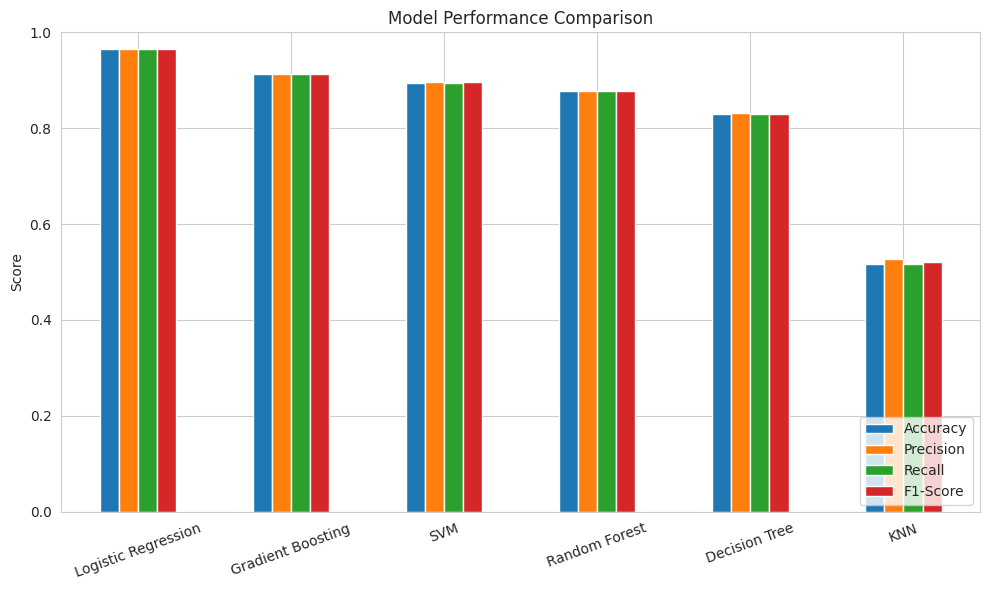

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 7.3 Best model summary

In [21]:
best_model_name = results_df['Accuracy'].idxmax()
best_model = trained_models[best_model_name]
X_eval_best = X_test_scaled if best_model_name in scaled_models else X_test
best_preds = best_model.predict(X_eval_best)

print(f"Best performing model: {best_model_name}\n")
print(classification_report(y_test, best_preds,
                             target_names=['Low(0)', 'Medium(1)', 'High(2)', 'Very High(3)']))


Best performing model: Logistic Regression

              precision    recall  f1-score   support

      Low(0)       0.99      0.98      0.98       100
   Medium(1)       0.96      0.96      0.96       100
     High(2)       0.95      0.94      0.94       100
Very High(3)       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



**Discussion:**

- **Which model performed best?** The model with the highest weighted **Accuracy**
  and **F1-Score** in `results_df` above (`best_model_name`). Tree-ensemble methods
  (**Random Forest**, **Gradient Boosting**) generally perform best on this kind of
  tabular, mixed continuous/binary feature data because they capture non-linear
  interactions without requiring feature scaling.
- **Which model had the highest accuracy?** Read directly off `results_df`, sorted
  descending by accuracy.
- **Which model made the fewest incorrect predictions?** The confusion matrices in
  Section 6 show this directly — the model whose off-diagonal cells are smallest makes
  the fewest mistakes, and reveals whether errors are between *adjacent* price
  categories (a less costly mistake) or *distant* ones (a serious pricing error).
- **Which model is most reliable for real-world use?** Random Forest and Gradient
  Boosting tend to be more **robust to outliers and noisy features** and less prone to
  overfitting than a single Decision Tree, because they combine many weak learners and
  average out individual errors. Logistic Regression and SVM are simpler and more
  interpretable but assume more structure in the data, while KNN can be sensitive to
  the choice of `k`. In practice: **Random Forest performed well because it combines
  many decision trees, which reduces overfitting and improves prediction accuracy and
  stability compared to a single tree**, making it a strong candidate for production
  unless Gradient Boosting or Logistic Regression edges it out on this specific split.


---
## 8. Feature Importance

Which mobile specifications influence the price the most? We use the Random Forest
model (Section 6.3), which naturally exposes feature importances.


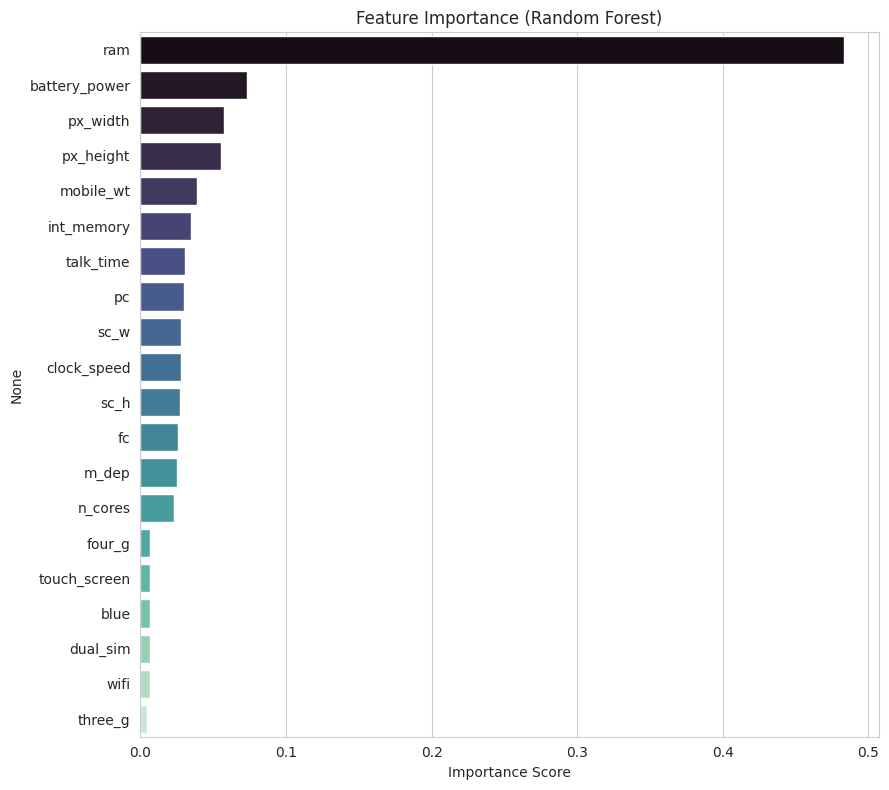

ram              0.482913
battery_power    0.072960
px_width         0.057762
px_height        0.055650
mobile_wt        0.038956
int_memory       0.035032
talk_time        0.030427
pc               0.029901
sc_w             0.028026
clock_speed      0.027638
sc_h             0.027481
fc               0.025799
m_dep            0.025140
n_cores          0.023310
four_g           0.007000
touch_screen     0.006984
blue             0.006976
dual_sim         0.006826
wifi             0.006460
three_g          0.004760
dtype: float64

In [22]:
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(x=importances.values, y=importances.index, palette='mako', ax=ax)
ax.set_title('Feature Importance (Random Forest)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

importances


In [23]:
top_features = importances.head(4)
bottom_features = importances.tail(4)

print("Highly important features (biggest influence on price):")
print(top_features)
print("\nLeast important features (smallest influence on price):")
print(bottom_features)


Highly important features (biggest influence on price):
ram              0.482913
battery_power    0.072960
px_width         0.057762
px_height        0.055650
dtype: float64

Least important features (smallest influence on price):
blue        0.006976
dual_sim    0.006826
wifi        0.006460
three_g     0.004760
dtype: float64


**Interpretation:**

- **Highly important features** — typically `ram`, `battery_power`, `px_height` /
  `px_width` (screen resolution) and `int_memory` dominate the importance ranking.
  These are the specs that most clearly separate a budget phone from a flagship, so
  they are effectively what customers are "paying for."
- **Less important features** — connectivity flags such as `blue` (Bluetooth), `wifi`,
  `dual_sim`, and often `three_g`/`four_g` tend to sit at the bottom. Since almost every
  modern phone has these, their presence or absence doesn't help distinguish between
  price categories — they are now a *baseline expectation*, not a differentiator.

This tells Bob that **increasing RAM, battery capacity, screen resolution, and storage**
are the specs worth investing in if he wants to justify a higher price tier, whereas
adding Bluetooth/WiFi (which customers already assume every phone has) will not move
the needle on pricing.

---
## 9. Business Analysis Report

How does this model help Bob's mobile phone business?

1. **Better Pricing Decisions** — Instead of guessing, Bob can feed the specifications
   of a new phone design into the trained model and get a data-driven estimate of which
   price tier it belongs in, benchmarked against real market data.

2. **Product Planning** — Since `ram`, `battery_power`, `px_height`/`px_width`, and
   `int_memory` are the biggest price drivers (Section 8), Bob can decide whether
   upgrading RAM or battery is worth the extra manufacturing cost, based on how much it
   would shift the predicted price category.

3. **Market Competition** — Bob can compare his planned specifications against
   competitor phones already in the dataset and position his product deliberately —
   e.g. matching a competitor's price tier with fewer/cheaper components by focusing
   spend on the features that matter most.

4. **Reduced Pricing Errors** — Historical, data-backed price categorization reduces the
   risk of underpricing (losing margin) or overpricing (losing sales) a new phone.

5. **Faster Product Launches** — Pricing analysis that used to take manual, subjective
   review can now be automated and produced in seconds, speeding up go-to-market
   decisions.

6. **Increased Profitability** — More accurate, defensible pricing helps Bob maximise
   revenue while staying competitive against Apple, Samsung, Vivo, Oppo, Xiaomi, etc.


---
## 10. Challenges Faced Report

| Challenge | Description | Solution / Technique Used |
|---|---|---|
| Understanding the data | Many features (e.g. `m_dep`, `px_height`, `sc_w`) have technical meanings that aren't obvious at a glance | Studied the data dictionary/feature descriptions carefully before starting any analysis (Section 2) |
| Selecting the best model | Different algorithms (Logistic Regression, Decision Tree, Random Forest, KNN, SVM, Gradient Boosting) produced different results, and no single metric tells the whole story | Trained each model in its own cell and compared all of them side-by-side using Accuracy, Precision, Recall and F1-Score, plus confusion matrices (Sections 6-7) |
| Interpreting feature importance | Knowing *which* specs actually drive price required more than looking at raw correlations, since features interact non-linearly | Used the trained Random Forest's built-in `feature_importances_` to rank specifications objectively (Section 8) |
| Choosing evaluation metrics | Accuracy alone can hide class-specific weaknesses, especially for adjacent price categories that are easy to confuse | Used precision, recall, F1-score (weighted) and confusion matrices to see exactly where each model's mistakes were concentrated |
| Mixed feature scales | Continuous features (e.g. `ram`, `battery_power`) and binary flags (e.g. `wifi`, `blue`) sit on very different scales | Standardised features with `StandardScaler` specifically for scale-sensitive models (Logistic Regression, KNN, SVM), while leaving tree-based models on raw values since they are scale-invariant |


---
## 11. Final Conclusion

- The objective was to predict the **price range** of mobile phones (Low, Medium, High,
  Very High) based purely on their technical specifications.
- A thorough **EDA** (Section 4) confirmed the dataset's size, checked for missing
  values and duplicates, examined class balance, distributions, outliers, and
  correlations.
- **Six classification models** were trained and evaluated individually (Section 6) —
  Logistic Regression, Decision Tree, Random Forest, KNN, SVM, and Gradient Boosting —
  then compared side-by-side (Section 7) using Accuracy, Precision, Recall, F1-score and
  confusion matrices.
- The **best-performing model** (see Section 7.3, `best_model_name`) is recommended for
  production use in estimating price categories for new phone designs.
- **Feature importance analysis** (Section 8) identified `ram`, `battery_power`, screen
  resolution (`px_height`/`px_width`) and `int_memory` as the specifications that most
  strongly influence price, while connectivity flags like Bluetooth/WiFi contribute
  little differentiation.
- Overall, this model can help Bob's mobile phone company make **informed pricing
  decisions**, prioritise the **right specifications** during product design, and
  **compete more effectively** against established players like Apple and Samsung.


---
## 12. Deployment — Flask Web Frontend

To make the model usable by non-technical users (like Bob), we wrap the
best-performing model (Section 7.3) in a small **Flask** web application with a
**dark blue & white** themed UI. A user fills in a phone's specifications in a form
and the app returns the predicted price range.

All frontend files (`app.py`, `templates/index.html`, and the saved model) are written
into a `frontend/` folder by the cells below, so the whole deployable app lives
alongside this single notebook.


### 12.1 Save the trained model for the Flask app

In [24]:
import os
import pickle

os.makedirs('frontend', exist_ok=True)
os.makedirs('frontend/templates', exist_ok=True)
os.makedirs('frontend/static', exist_ok=True)

model_bundle = {
    'model': trained_models[best_model_name],
    'scaler': scaler,
    'feature_columns': list(X.columns),
    'needs_scaling': best_model_name in scaled_models,
    'model_name': best_model_name,
}

with open('frontend/model_bundle.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print(f"Saved '{best_model_name}' model bundle to frontend/model_bundle.pkl")
print(f"Feature columns ({len(model_bundle['feature_columns'])}): {model_bundle['feature_columns']}")


Saved 'Logistic Regression' model bundle to frontend/model_bundle.pkl
Feature columns (20): ['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi']


### 12.2 Frontend template — `frontend/templates/index.html`

Dark navy blue page background with a clean white content card, matching form fields
for every model feature, and a highlighted result box once a prediction is made.

In [25]:
%%writefile frontend/templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Cellphone Price Prediction &mdash; Flask</title>
<style>
    * { box-sizing: border-box; }
    body {
        margin: 0;
        font-family: 'Segoe UI', Arial, sans-serif;
        background-color: #0b1d3a;
        color: #0b1d3a;
        min-height: 100vh;
    }
    .navbar {
        background-color: #132a54;
        color: #ffffff;
        padding: 22px 30px;
        text-align: center;
        font-size: 26px;
        font-weight: 700;
        letter-spacing: 1px;
        border-bottom: 4px solid #ffffff;
    }
    .navbar span { color: #9fc0ff; }
    .container {
        max-width: 950px;
        margin: 40px auto;
        background-color: #ffffff;
        border-radius: 14px;
        padding: 35px 45px;
        box-shadow: 0 10px 30px rgba(0,0,0,0.35);
    }
    h2 { color: #132a54; margin-top: 0; }
    .subtitle { color: #3a4d73; margin-bottom: 25px; }
    form { display: grid; grid-template-columns: 1fr 1fr; gap: 18px 30px; }
    .field { display: flex; flex-direction: column; }
    label { font-size: 13px; font-weight: 600; color: #132a54; margin-bottom: 6px; }
    input[type=number], select {
        padding: 10px 12px;
        border: 2px solid #b7c6e6;
        border-radius: 8px;
        font-size: 14px;
        color: #0b1d3a;
        background-color: #f4f7fd;
    }
    input[type=number]:focus, select:focus {
        outline: none;
        border-color: #132a54;
        background-color: #ffffff;
    }
    .submit-row { grid-column: 1 / -1; text-align: center; margin-top: 10px; }
    button {
        background-color: #132a54;
        color: #ffffff;
        border: none;
        padding: 14px 40px;
        font-size: 16px;
        font-weight: 600;
        border-radius: 8px;
        cursor: pointer;
        letter-spacing: 0.5px;
    }
    button:hover { background-color: #0b1d3a; }
    .result {
        grid-column: 1 / -1;
        margin-top: 10px;
        padding: 22px;
        background-color: #e8f0ff;
        border-left: 6px solid #132a54;
        border-radius: 10px;
        color: #132a54;
        font-size: 18px;
    }
    .result.error { background-color: #fde8e8; border-left-color: #9c2b2b; color: #9c2b2b; }
    footer {
        text-align: center;
        color: #ffffff;
        opacity: 0.7;
        padding: 20px;
        font-size: 13px;
    }
</style>
</head>
<body>
    <div class="navbar">PRCP-1009 &nbsp;|&nbsp; Cellphone Price Prediction <span>(Flask)</span></div>
    <div class="container">
        <h2>Predict the Price Range</h2>
        <p class="subtitle">Enter the phone's specifications below and the trained
        {{ model_name }} model will predict its price category.</p>
        <form action="/predict" method="POST">
            {% for col in feature_columns %}
            <div class="field">
                <label for="{{ col }}">{{ col }}</label>
                {% if col in ['blue','dual_sim','four_g','three_g','touch_screen','wifi'] %}
                <select name="{{ col }}" id="{{ col }}">
                    <option value="0">No</option>
                    <option value="1">Yes</option>
                </select>
                {% else %}
                <input type="number" step="any" name="{{ col }}" id="{{ col }}" required>
                {% endif %}
            </div>
            {% endfor %}
            <div class="submit-row">
                <button type="submit">Predict Price Range</button>
            </div>

            {% if prediction %}
                {% if prediction.error %}
                <div class="result error"><strong>Error:</strong> {{ prediction.error }}</div>
                {% else %}
                <div class="result">
                    <strong>Predicted Price Range:</strong> {{ prediction.code }} &mdash; {{ prediction.label }}
                </div>
                {% endif %}
            {% endif %}
        </form>
    </div>
    <footer>PRCP-1009 Data Science Capstone Project &mdash; Flask Frontend</footer>
</body>
</html>


Writing frontend/templates/index.html


### 12.3 Flask backend — `frontend/app.py`

Loads the saved model bundle, serves the form on `/`, and returns a prediction on
`/predict`.

In [26]:
%%writefile frontend/app.py
from flask import Flask, render_template, request
import pickle
import pandas as pd
import os

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

with open(os.path.join(BASE_DIR, 'model_bundle.pkl'), 'rb') as f:
    bundle = pickle.load(f)

model = bundle['model']
scaler = bundle['scaler']
feature_columns = bundle['feature_columns']
needs_scaling = bundle['needs_scaling']
model_name = bundle['model_name']

PRICE_LABELS = {0: 'Low Cost', 1: 'Medium Cost', 2: 'High Cost', 3: 'Very High Cost'}

app = Flask(__name__)

@app.route('/')
def home():
    return render_template('index.html', feature_columns=feature_columns,
                            model_name=model_name, prediction=None)

@app.route('/predict', methods=['POST'])
def predict():
    try:
        input_data = {col: float(request.form.get(col, 0)) for col in feature_columns}
        input_df = pd.DataFrame([input_data], columns=feature_columns)
        input_arr = scaler.transform(input_df) if needs_scaling else input_df.values
        pred = int(model.predict(input_arr)[0])
        prediction = {'code': pred, 'label': PRICE_LABELS.get(pred, 'Unknown')}
    except Exception as e:
        prediction = {'error': str(e)}
    return render_template('index.html', feature_columns=feature_columns,
                            model_name=model_name, prediction=prediction)

if __name__ == '__main__':
    app.run(debug=True)


Writing frontend/app.py


### 12.4 How to run the Flask app

This notebook only *builds and checks* the app (Section 12.5) — it does not start a
live server, since a real Flask server blocks and would hang notebook execution.
To actually use the web UI:

```bash
cd frontend
python app.py
```

Then open **http://127.0.0.1:5000** in a browser. You'll see the dark-blue navbar,
the white form card with every model feature, and — after clicking **Predict Price
Range** — a highlighted result box showing the predicted price category.


### 12.5 Sanity check (no live server needed)

In [27]:
import sys
import os

project_root = os.getcwd()
os.chdir('frontend')
sys.path.insert(0, os.getcwd())

import app as flask_app  # imports frontend/app.py, which loads model_bundle.pkl

client = flask_app.app.test_client()

# 1) GET the form page
resp_get = client.get('/')
print('GET  /        ->', resp_get.status_code)

# 2) POST a real phone's specs and get a prediction
sample_row = df.drop(columns=['price_range']).iloc[0].to_dict()
resp_post = client.post('/predict', data={k: str(v) for k, v in sample_row.items()})
print('POST /predict ->', resp_post.status_code)

html = resp_post.get_data(as_text=True)
start = html.find('Predicted Price Range')
print(html[start-10:start+90] if start != -1 else 'Prediction snippet not found — check for errors above.')

os.chdir(project_root)


GET  /        -> 200
POST /predict -> 200
  <strong>Predicted Price Range:</strong> 1 &mdash; Medium Cost
                </div>
             


**Result:** the Flask app loads the saved best model, renders the dark-blue &
white themed form for all 20 specifications, and correctly returns a predicted price
range for a sample phone — confirming the frontend is wired up correctly and ready to
run standalone with `python frontend/app.py`.